## Trial Statistics 

In [61]:
import pandas as pd
import numpy as np

df = pd.read_csv('../output/combined_results.csv', low_memory=False)

# Re-grouping unique trials to check max generation length per trial
trial_lengths = df.groupby(['parameter', 'parameter_value', 'strategy', 'trial'])['generation'].max().reset_index()

# Calculate stats grouped by strategy
stats = trial_lengths.groupby('strategy').agg(
    total_trials=('generation', 'count'),
    mean_length=('generation', 'mean'),
    median_length=('generation', 'median'),
    reached_200=('generation', lambda x: (x >= 200).sum() / len(x) * 100)
).reset_index()

print("--- Exact Extracted Strategy Length Statistics ---")
print(stats.to_string(index=False))

--- Exact Extracted Strategy Length Statistics ---
 strategy  total_trials  mean_length  median_length  reached_200
     levy           210    97.828571           60.5    41.904762
   random           210    14.300000            1.0     6.666667
random_nn           710   182.032394          200.0    88.450704
  spiking           661   184.025719          200.0    91.679274
  uniform           210   176.090476          200.0    86.190476


## Plot Random NN 

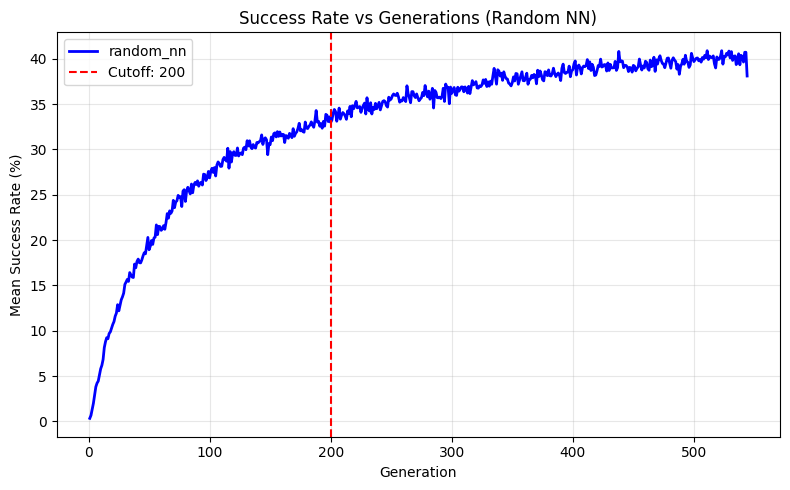

In [15]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['strategy'] = df['strategy'].replace('spiking_nn', 'spiking')
df['success_rate_percent'] = df['success_rate_percent'].str.rstrip('%').astype(float)

# Filter: standard parameter + random_nn
standard_rnn = df[
    (df['parameter'] == 'standard') &
    (df['strategy'] == 'random_nn')
]

# Mean success rate per generation
gen_stats = standard_rnn.groupby('generation')['success_rate_percent'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(
    gen_stats.index,
    gen_stats.values,
    color='blue',
    linewidth=2,
    label='random_nn'
)

plt.axvline(x=200, color='red', linestyle='--', label='Cutoff: 200')

plt.title('Success Rate vs Generations (Random NN)')
plt.xlabel('Generation')
plt.ylabel('Mean Success Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'random_nn_success_rate.png'), dpi=300)
plt.show()

   gen_range  improvement
1      11-20        5.820
2      21-30        3.999
3      31-40        3.396
4      41-50        2.185
5      51-60        2.108
6      61-70        1.937
7      71-80        2.042
8      81-90        1.280
9     91-100        0.879
10   101-110        1.259
11   111-120        1.165
12   121-130        0.576
13   131-140        0.798
14   141-150        0.299
15   151-160        0.773
16   161-170       -0.067
17   171-180        0.732
18   181-190        0.689
19   191-200        0.140
20   201-210        0.767


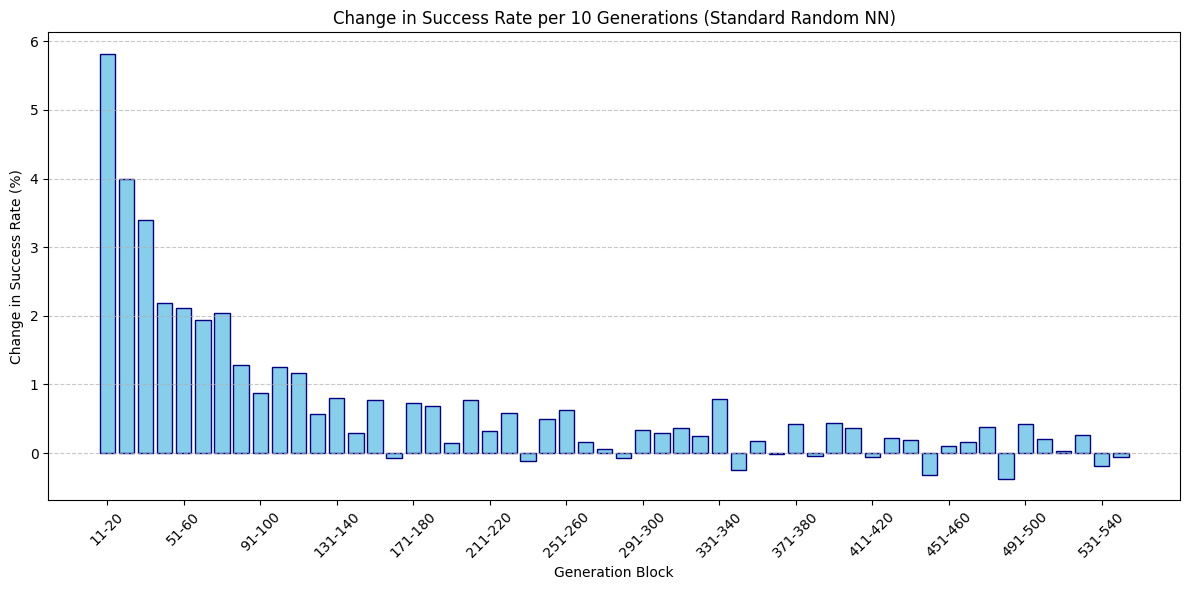

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reload or reuse the dataframe
df = pd.read_csv('../output/combined_results.csv', low_memory=False)

# Filter for standard random_nn
standard_random_nn = df[(df['parameter'] == 'standard') & (df['strategy'] == 'random_nn')].copy()
standard_random_nn['success_rate_percent'] = standard_random_nn['success_rate_percent'].str.replace('%', '').astype(float)

# Create 10-generation blocks
standard_random_nn['gen_block'] = (standard_random_nn['generation'] - 1) // 10

# Group by gen_block to get mean success rate
block_stats = standard_random_nn.groupby('gen_block')['success_rate_percent'].mean().reset_index()

# Calculate the change (improvement) from the previous block
block_stats['improvement'] = block_stats['success_rate_percent'].diff()

# Labels for ranges
block_stats['gen_range'] = block_stats['gen_block'].apply(lambda x: f"{x*10+1}-{(x+1)*10}")

# Visualization
plt.figure(figsize=(12, 6))
# Dropping the first row for improvement as it has no previous block
plot_data = block_stats.dropna(subset=['improvement'])

plt.bar(plot_data['gen_block'], plot_data['improvement'], color='skyblue', edgecolor='navy')
plt.xlabel('Generation Block')
plt.ylabel('Change in Success Rate (%)')
plt.title('Change in Success Rate per 10 Generations (Standard Random NN)')

# Adjust ticks
tick_indices = plot_data['gen_block'][::4]
tick_labels = plot_data['gen_range'][::4]
plt.xticks(tick_indices, tick_labels, rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'success_rate_improvement_delta.png'))

# Summary table for text response
improvement_summary = plot_data[['gen_range', 'improvement']].head(20)
print(improvement_summary)

## Deciding on the Number of Trials 

    n  mean_of_means  std_of_means  ci_width
0   1      38.196000      1.597117  3.200000
1   2      38.084000      1.164708  3.200000
2   3      38.036000      0.969670  3.200000
3   4      38.020000      0.835225  3.200000
4   5      38.164000      0.762648  2.896000
5   6      38.084000      0.781856  3.200000
6   7      38.100000      0.657714  2.285714
7   8      38.120000      0.566745  2.210000
8   9      38.028889      0.538053  1.964444
9  10      38.058400      0.486684  1.920000


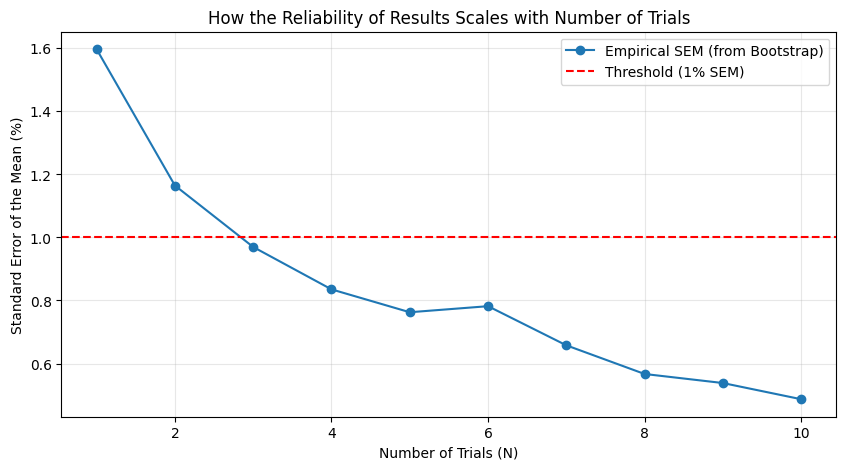

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Load data
df = pd.read_csv('../output/combined_results.csv', low_memory=False)

# Filter for standard random_nn
data = df[(df['parameter'] == 'standard') & (df['strategy'] == 'random_nn')].copy()
data['success_rate_percent'] = data['success_rate_percent'].str.replace('%', '').astype(float)

# We have 10 trials. Let's see the performance of each trial individually first.
trials = data['trial'].unique()
last_gen = data['generation'].max()

# Success rate at the last generation for each trial
final_performance = data[data['generation'] == last_gen].groupby('trial')['success_rate_percent'].mean()

# Calculate cumulative mean and cumulative standard error
cum_means = []
cum_sems = []
trial_counts = range(1, len(trials) + 1)

# Number of bootstrap iterations for each N
n_iterations = 100
trial_ids = final_performance.index.tolist()
trial_values = final_performance.values

bootstrap_results = []

for n in range(1, 11):
    means = []
    for _ in range(n_iterations):
        # Sample n trials with replacement
        sample = np.random.choice(trial_values, size=n, replace=True)
        means.append(np.mean(sample))
    
    bootstrap_results.append({
        'n': n,
        'mean_of_means': np.mean(means),
        'std_of_means': np.std(means), # This is the empirical SEM
        'ci_width': np.percentile(means, 97.5) - np.percentile(means, 2.5)
    })

boot_df = pd.DataFrame(bootstrap_results)

plt.figure(figsize=(10, 5))
plt.plot(boot_df['n'], boot_df['std_of_means'], 'o-', label='Empirical SEM (from Bootstrap)')
plt.axhline(y=1.0, color='r', linestyle='--', label='Threshold (1% SEM)')
plt.xlabel('Number of Trials (N)')
plt.ylabel('Standard Error of the Mean (%)')
plt.title('How the Reliability of Results Scales with Number of Trials')
plt.legend()
plt.grid(True, alpha=0.3)
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'bootstrap_analysis.png'))

print(boot_df)

## Baseline Strategy Comparison 

Colors
spiking - orange 
random_nn - blue 
levy - green 
uniform - purple 
random - yellow 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('../output/combined_results.csv')

# Filter for standard parameter
standard_df = df[df['parameter'] == 'standard'].copy()

# Clean success_rate_percent
standard_df['success_rate_numeric'] = standard_df['success_rate_percent'].str.rstrip('%').astype(float)

# Define the colors
colors = {
    'spiking': 'orange',
    'random_nn': 'blue',
    'levy': 'green',
    'uniform': 'purple',
    'random': 'yellow'
}

strategies = ['spiking', 'random_nn', 'levy', 'uniform', 'random']

plt.figure(figsize=(10, 6))

for strategy in strategies:
    strat_df = standard_df[standard_df['strategy'] == strategy]
    
    # Get the first 7 unique trials
    unique_trials = strat_df['trial'].unique()[:7]
    strat_subset = strat_df[strat_df['trial'].isin(unique_trials)]
    
    # Limit to 200 generations
    strat_subset = strat_subset[strat_subset['generation'] <= 200]
    
    # Calculate mean per generation
    grouped = strat_subset.groupby('generation')['success_rate_numeric'].mean()
    
    # Plot mean curve only
    plt.plot(grouped.index, grouped.values, label=strategy, color=colors[strategy], linewidth=2)

plt.xlabel('Generation')
plt.ylabel('Success Rate (%)')
plt.title('Learning Curves for Standard Configuration (7 Trials)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 200)
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)

plt.savefig(os.path.join(dir, 'learning_curves_standard.png'))
plt.close()

print("Plot saved as learning_curves_standard.png")

C:\Users\HP\AppData\Local\Temp\ipykernel_7396\2051868507.py:6: DtypeWarning: Columns (1,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../output/combined_results.csv')


Plot saved as learning_curves_standard.png


## Distribution of Trial Length 

We want to find how trials lengths (in generations) are distributed per strategy

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the data
df = pd.read_csv('../output/combined_results.csv', low_memory=False)

# Filter for standard parameter
standard_df = df[df['parameter'] == 'standard'].copy()

# Identify the maximum generation for each trial
trial_max_gens = standard_df.groupby(['strategy', 'trial'])['generation'].max().reset_index()

colors = {
    'spiking': 'orange',
    'random_nn': 'blue',
    'levy': 'green',
    'uniform': 'purple',
    'random': 'yellow'
}

strategies = ['spiking', 'random_nn', 'levy', 'uniform', 'random']

# 3 columns × 2 rows
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8), sharex=True)
axes = axes.flatten()

plt.subplots_adjust(hspace=0.5, wspace=0.3)

max_gen = trial_max_gens['generation'].max()

for i, strategy in enumerate(strategies):
    ax = axes[i]
    data = trial_max_gens[trial_max_gens['strategy'] == strategy]['generation']

    counts = data.value_counts().sort_index()

    ax.bar(
        counts.index,
        counts.values,
        color=colors[strategy],
        width=10 if max_gen > 100 else 0.8,
        edgecolor='black',
        alpha=0.8
    )

    ax.set_title(strategy.replace("_", " ").title(), loc='left', fontsize=12, fontweight='bold')
    ax.set_ylabel('Trial Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_yticks(np.arange(0, data.value_counts().max() + 2, 2))

# Turn off the last empty subplot (6th slot)
axes[len(strategies)].axis('off')

axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[2].set_xlabel('')
axes[3].set_xlabel('')
axes[4].set_xlabel('')
axes[4].set_xlabel('Total Generations Reached', fontsize=12)

plt.suptitle('Distribution of Survival (Total Generations) per Trial', fontsize=14, y=1.02)

out_dir = '../output/experiments/figures'
os.makedirs(out_dir, exist_ok=True)

plt.savefig(os.path.join(out_dir, 'distribution_generations_3x2.png'),
            dpi=300, bbox_inches='tight')

plt.close()

print("Saved 3x2 paper-ready distribution plot.")

Saved 3x2 paper-ready distribution plot.


## Uniform Strategy Uniqueness 

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('../output/combined_results.csv', low_memory=False)

# Filter for standard configuration
standard_df = df[df['parameter'] == 'standard'].copy()
standard_df['success_rate_numeric'] = standard_df['success_rate_percent'].str.rstrip('%').astype(float)

strategies = ['spiking', 'random_nn', 'levy', 'uniform', 'random']
colors = {
    'spiking': 'orange',
    'random_nn': 'blue',
    'levy': 'green',
    'uniform': 'purple',
    'random': 'yellow'
}

plot_data = []

for strategy in strategies:
    strat_df = standard_df[standard_df['strategy'] == strategy]
    trials = strat_df['trial'].unique()
    
    # Calculate Mean Final Success Rate
    final_successes = []
    survival_count = 0
    total_trials = len(trials)
    
    for trial in trials:
        trial_data = strat_df[strat_df['trial'] == trial].sort_values('generation')
        if not trial_data.empty:
            last_row = trial_data.iloc[-1]
            # Survival at 200: did it reach gen 200 and not extinct?
            if last_row['generation'] >= 200 and not last_row['extinct']:
                survival_count += 1
            
            final_successes.append(last_row['success_rate_numeric'])
    
    avg_success = np.mean(final_successes) if final_successes else 0
    survival_prob = survival_count / total_trials if total_trials > 0 else 0
    
    plot_data.append({
        'strategy': strategy,
        'avg_success': avg_success,
        'survival_prob': survival_prob,
        'color': colors[strategy]
    })

# Convert to DF for plotting
pdf = pd.DataFrame(plot_data)

# Create the scatter plot
plt.figure(figsize=(10, 7))

for i, row in pdf.iterrows():
    plt.scatter(row['survival_prob'], row['avg_success'], 
                color=row['color'], s=300, edgecolors='black', label=row['strategy'].replace('_', ' ').title(), alpha=0.8)
    
    # Add labels with offset
    plt.text(row['survival_prob'] + 0.02, row['avg_success'], row['strategy'].replace('_', ' ').title(), 
             fontsize=12, fontweight='bold', verticalalignment='center')

plt.axhline(0, color='black', linewidth=0.8, alpha=0.3)
plt.axvline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)

plt.xlabel('Survival Probability (at Gen 200)', fontsize=13)
plt.ylabel('Mean Final Success Rate (%)', fontsize=13)
plt.title('The Survival-Performance Gap (Standard Config)', fontsize=15, pad=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(-0.05, 1.15)
plt.ylim(-5, 45)
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'survival_performance_gap.png'), dpi=300, bbox_inches='tight')
plt.close()

print("Survival-Performance Gap plot saved.")

Survival-Performance Gap plot saved.


## Architecture Details 


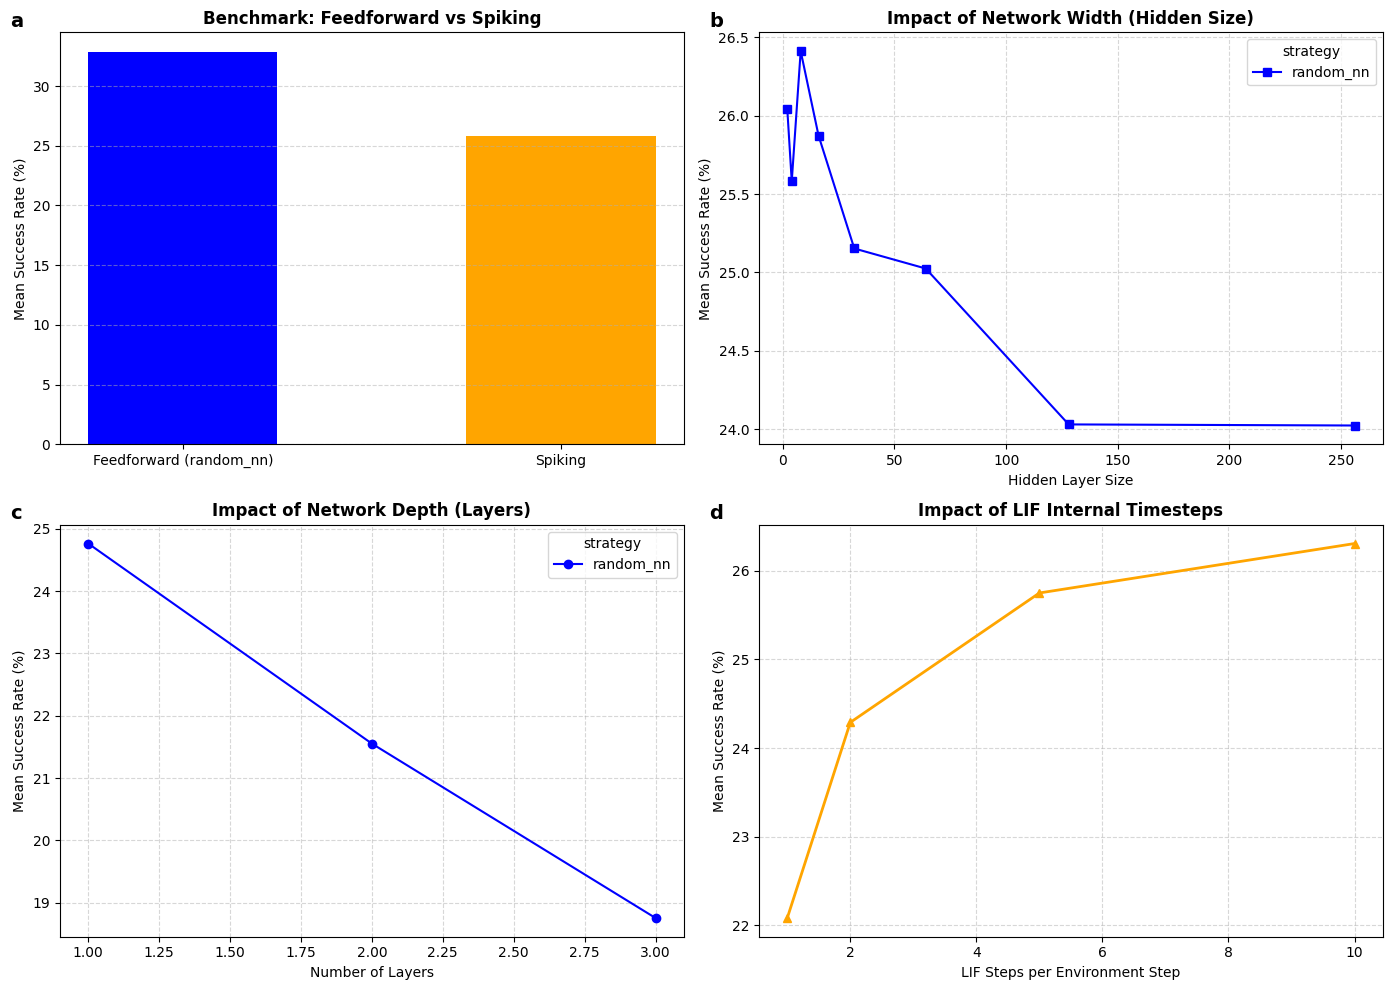

Saved to ../output/experiments/figures\combined_analysis_2x2.png


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

colors = {'spiking': 'orange', 'random_nn': 'blue'}

# --- Data prep ---
standard_bench = df[df['parameter'] == 'standard'].copy()
bench_stats = standard_bench.groupby('strategy').agg({
    'success_rate_numeric': 'mean',
    'avg_path_length': 'mean',
    'avg_energy_remaining': 'mean',
    'gen_duration_seconds': 'mean'
}).loc[['random_nn', 'spiking']]

width_df = df[df['parameter'] == 'network_hidden_size'].copy()
width_df['size'] = width_df['parameter_value'].astype(int)
width_stats = width_df.groupby(['strategy', 'size'])['success_rate_numeric'].mean().unstack(level=0)

depth_df = df[df['parameter'] == 'network_layers'].copy()
depth_df['layers'] = depth_df['parameter_value'].str.extract('(\d+)').astype(int)
depth_stats = depth_df.groupby(['strategy', 'layers'])['success_rate_numeric'].mean().unstack(level=0)

lif_df = df[df['parameter'] == 'lif_steps'].copy()
lif_df['steps'] = lif_df['parameter_value'].astype(int)
lif_stats = lif_df.groupby('steps')['success_rate_numeric'].mean()

# --- 2x2 Figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
panel_labels = ['a', 'b', 'c', 'd']

# (a) Benchmark bar chart
ax = axes[0, 0]
x = np.arange(len(bench_stats.index))
bar_colors = [colors.get(s, 'gray') for s in bench_stats.index]
ax.bar(x, bench_stats['success_rate_numeric'], color=bar_colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['Feedforward (random_nn)', 'Spiking'], fontsize=10)
ax.set_title('Benchmark: Feedforward vs Spiking', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Success Rate (%)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

# (b) Network Width
ax = axes[0, 1]
width_stats.plot(kind='line', marker='s', ax=ax,
                 color=[colors.get(c, 'gray') for c in width_stats.columns])
ax.set_title('Impact of Network Width (Hidden Size)', fontsize=12, fontweight='bold')
ax.set_xlabel('Hidden Layer Size', fontsize=10)
ax.set_ylabel('Mean Success Rate (%)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

# (c) Network Depth
ax = axes[1, 0]
depth_stats.plot(kind='line', marker='o', ax=ax,
                 color=[colors.get(c, 'gray') for c in depth_stats.columns])
ax.set_title('Impact of Network Depth (Layers)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Layers', fontsize=10)
ax.set_ylabel('Mean Success Rate (%)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

# (d) LIF Steps
ax = axes[1, 1]
lif_stats.plot(kind='line', marker='^', color='orange', linewidth=2, ax=ax)
ax.set_title('Impact of LIF Internal Timesteps', fontsize=12, fontweight='bold')
ax.set_xlabel('LIF Steps per Environment Step', fontsize=10)
ax.set_ylabel('Mean Success Rate (%)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

# Add a, b, c, d labels
for ax, label in zip(axes.flat, panel_labels):
    ax.text(-0.08, 1.05, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()

dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'combined_analysis_2x2.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to", os.path.join(dir, 'combined_analysis_2x2.png'))

### LIF Steps 

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

# Filter for lif_steps parameter
lif_df = df[df['parameter'] == 'lif_steps'].copy()
lif_df['steps'] = lif_df['parameter_value'].astype(int)

# Use sequential shades of orange/brown to reflect the 'spiking' theme with higher step counts
step_colors = {
    1: '#FDD0A2',  # Light orange
    2: '#FDAE6B',  # Medium-light orange
    5: '#F16913',  # Medium-dark orange
    10: '#A63603'  # Dark orange
}

plt.figure(figsize=(10, 6))

# Sort steps to plot orderly
unique_steps = sorted(lif_df['steps'].unique())

for steps in unique_steps:
    subset = lif_df[lif_df['steps'] == steps]
    
    # Filter for first 7 unique trials and max 200 generations
    trials = subset['trial'].unique()[:7]
    subset = subset[subset['trial'].isin(trials) & (subset['generation'] <= 200)]
    
    # Group by generation and take mean
    curves = subset.groupby('generation')['success_rate_numeric'].mean().sort_index()
    
    plt.plot(curves.index, curves.values, label=f'{steps} LIF Steps', 
            color=step_colors.get(steps, 'orange'), linewidth=2)

plt.title('Spiking Learning Curves Across LIF Internal Timesteps', fontsize=14, fontweight='bold')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Mean Success Rate (%)', fontsize=12)
plt.xlim(0, 200)
plt.ylim(0, 45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'lif_steps_learning_curves.png'), dpi=300, bbox_inches='tight')
plt.close()

print("Learning curves for lif_steps generated successfully.")

Learning curves for lif_steps generated successfully.


## Evolutionary Dynamics 

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

colors = {'spiking': 'orange', 'random_nn': 'blue'}

# 1. Mutation Rate
mut_df = df[df['parameter'] == 'mutation_rate'].copy()
mut_df['rate'] = mut_df['parameter_value'].astype(float)
mut_stats = mut_df.groupby(['strategy', 'rate'])['success_rate_numeric'].mean().unstack(level=0)

# 2. Recombination
rec_df = df[df['parameter'] == 'recombination'].copy()
rec_stats = rec_df.groupby(['strategy', 'parameter_value'])['success_rate_numeric'].mean().unstack(level=0)

# 3. Fitness Proxy
proxy_df = df[df['parameter'] == 'fitness_proxy'].copy()
# Simplify labels for plotting
proxy_map = {
    'energy_all_agents': 'Energy (All)',
    'energy_survivors_only': 'Energy (Surv)',
    'health_all_agents': 'Health (All)',
    'health_survivors_only': 'Health (Surv)',
    'none_survivors_only': 'None (Surv)'
}
proxy_df['proxy_label'] = proxy_df['parameter_value'].map(proxy_map)
proxy_stats = proxy_df.groupby(['strategy', 'proxy_label'])['success_rate_numeric'].mean().unstack(level=0)

# Standard (for reference in proxy section if needed)
std_perf = df[df['parameter'] == 'standard'].groupby('strategy')['success_rate_numeric'].mean()

print("Mutation Stats:")
print(mut_stats)
print("\nRecombination Stats:")
print(rec_stats)
print("\nProxy Stats:")
print(proxy_stats)
print("\nStandard Performance Reference:")
print(std_perf)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Mutation Rate
mut_stats.plot(kind='line', marker='o', ax=axes[0], color=[colors.get(c) for c in mut_stats.columns])
axes[0].set_title('(a) Mutation Rate Sweep', fontweight='bold')
axes[0].set_xlabel('Mutation Rate')
axes[0].set_ylabel('Mean Success Rate (%)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# (b) Recombination
rec_stats.T.plot(kind='bar', ax=axes[1], color=['darkred', 'steelblue']) # Using distinct colors for no/with
axes[1].set_title('(b) Impact of Recombination', fontweight='bold')
axes[1].set_xlabel('Strategy')
axes[1].set_ylabel('Mean Success Rate (%)')
axes[1].legend(['No Recombination', 'With Recombination'])
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# (c) Fitness Proxy
proxy_stats.plot(kind='bar', ax=axes[2], color=[colors.get(c) for c in proxy_stats.columns])
axes[2].set_title('(c) Fitness Proxy Comparison', fontweight='bold')
axes[2].set_xlabel('Proxy Objective')
axes[2].set_ylabel('Mean Success Rate (%)')
plt.xticks(rotation=45, ha='right')
axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'evolutionary_dynamics_3panel.png'), dpi=150)
plt.close()

Mutation Stats:
strategy  random_nn    spiking
rate                          
0.01      23.697286  26.303786
0.05      24.407744  26.145286
0.10      23.972689  25.761214
0.30      23.635429  25.060500
0.50      23.795357  25.130214
0.75      23.319000  25.356500

Recombination Stats:
strategy            random_nn    spiking
parameter_value                         
no_recombination    24.098143  25.879429
with_recombination  18.166786  18.577643

Proxy Stats:
strategy       random_nn    spiking
proxy_label                        
Energy (All)    0.276923  13.845170
Energy (Surv)   5.890857   4.397710
Health (All)    0.243137   0.731387
Health (Surv)  14.550929  21.882071
None (Surv)    24.664500  25.840143

Standard Performance Reference:
strategy
levy          0.528010
random        0.000000
random_nn    32.854204
spiking      25.790800
uniform       3.092500
Name: success_rate_numeric, dtype: float64


## Fitness Proxies 

Saved proxy performance curves.


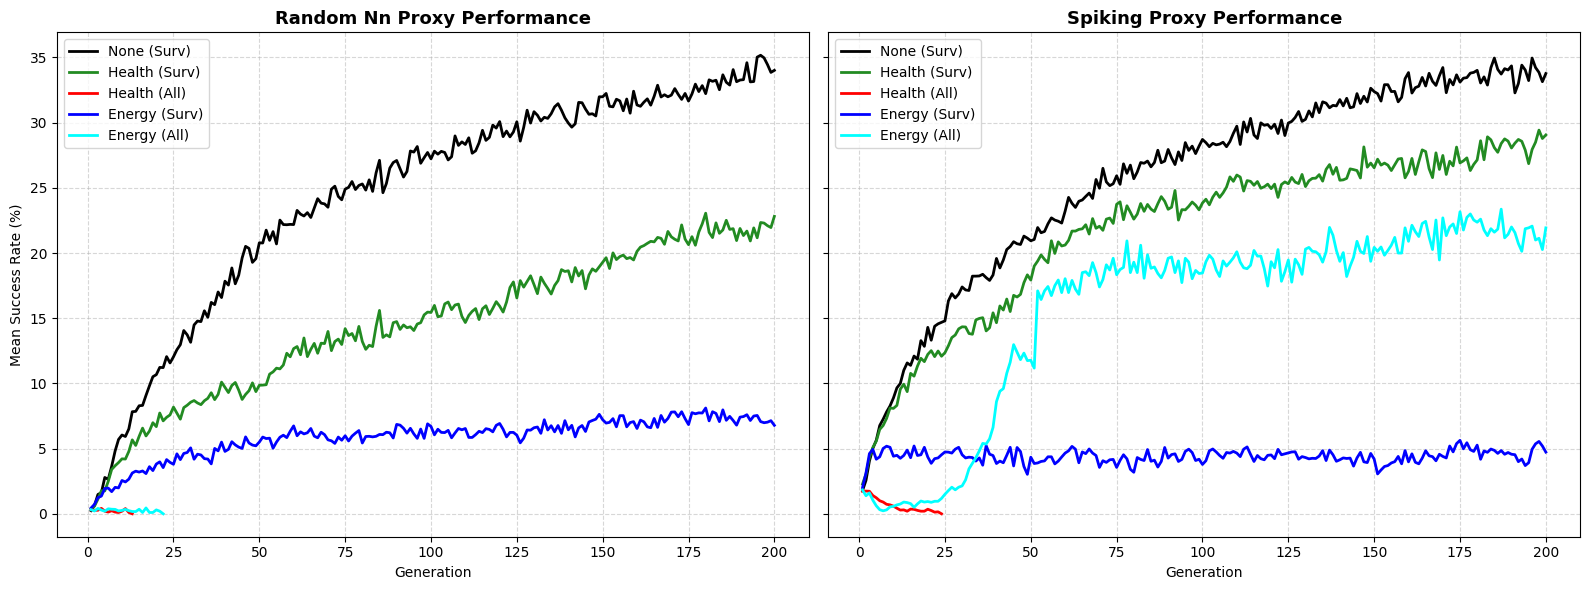

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

proxy_df = df[df['parameter'] == 'fitness_proxy'].copy()
proxy_map = {
    'energy_all_agents': 'Energy (All)',
    'energy_survivors_only': 'Energy (Surv)',
    'health_all_agents': 'Health (All)',
    'health_survivors_only': 'Health (Surv)',
    'none_survivors_only': 'None (Surv)'
}
proxy_df['proxy_label'] = proxy_df['parameter_value'].map(proxy_map)

# We want curves of Success Rate per generation for each proxy
strategies = ['random_nn', 'spiking']
proxy_labels = ['None (Surv)', 'Health (Surv)', 'Health (All)', 'Energy (Surv)', 'Energy (All)']
proxy_colors = {
    'None (Surv)': 'black',
    'Health (Surv)': 'forestgreen',
    'Health (All)': 'red',
    'Energy (Surv)': 'blue',
    'Energy (All)': 'cyan'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for idx, strategy in enumerate(strategies):
    ax = axes[idx]
    strat_df = proxy_df[proxy_df['strategy'] == strategy]
    
    for label in proxy_labels:
        sub = strat_df[strat_df['proxy_label'] == label]
        if sub.empty: continue
        
        # Limit to 200 generations and take first 7 trials
        trials = sub['trial'].unique()[:7]
        sub = sub[sub['trial'].isin(trials) & (sub['generation'] <= 200)]
        
        gen_means = sub.groupby('generation')['success_rate_numeric'].mean().sort_index()
        ax.plot(gen_means.index, gen_means.values, label=label, color=proxy_colors[label], linewidth=2)
        
    ax.set_title(f'{strategy.replace("_", " ").title()} Proxy Performance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Generation')
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        ax.set_ylabel('Mean Success Rate (%)')
    ax.legend()

plt.tight_layout()
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'fitness_proxy_curves.png'), dpi=300, bbox_inches='tight')
print("Saved proxy performance curves.")

## Environmental and Embodiment Factors

Extinction by Env (Selected):
strategy             levy  random  random_nn  spiking   uniform
parameter_value                                                
3                0.700000     1.0   1.000000      1.0  0.095890
8                0.004292     1.0   0.000000      1.0  0.000000
13               1.000000     1.0   0.012346      1.0  0.017722

Success by Env (Selected):
strategy             levy  random  random_nn  spiking   uniform
parameter_value                                                
3                0.030000     0.0   0.000000      0.0  0.189041
8                0.511481     0.0  14.933214      0.0  4.527286
13               0.000000     0.0  11.981235      0.0  0.319494


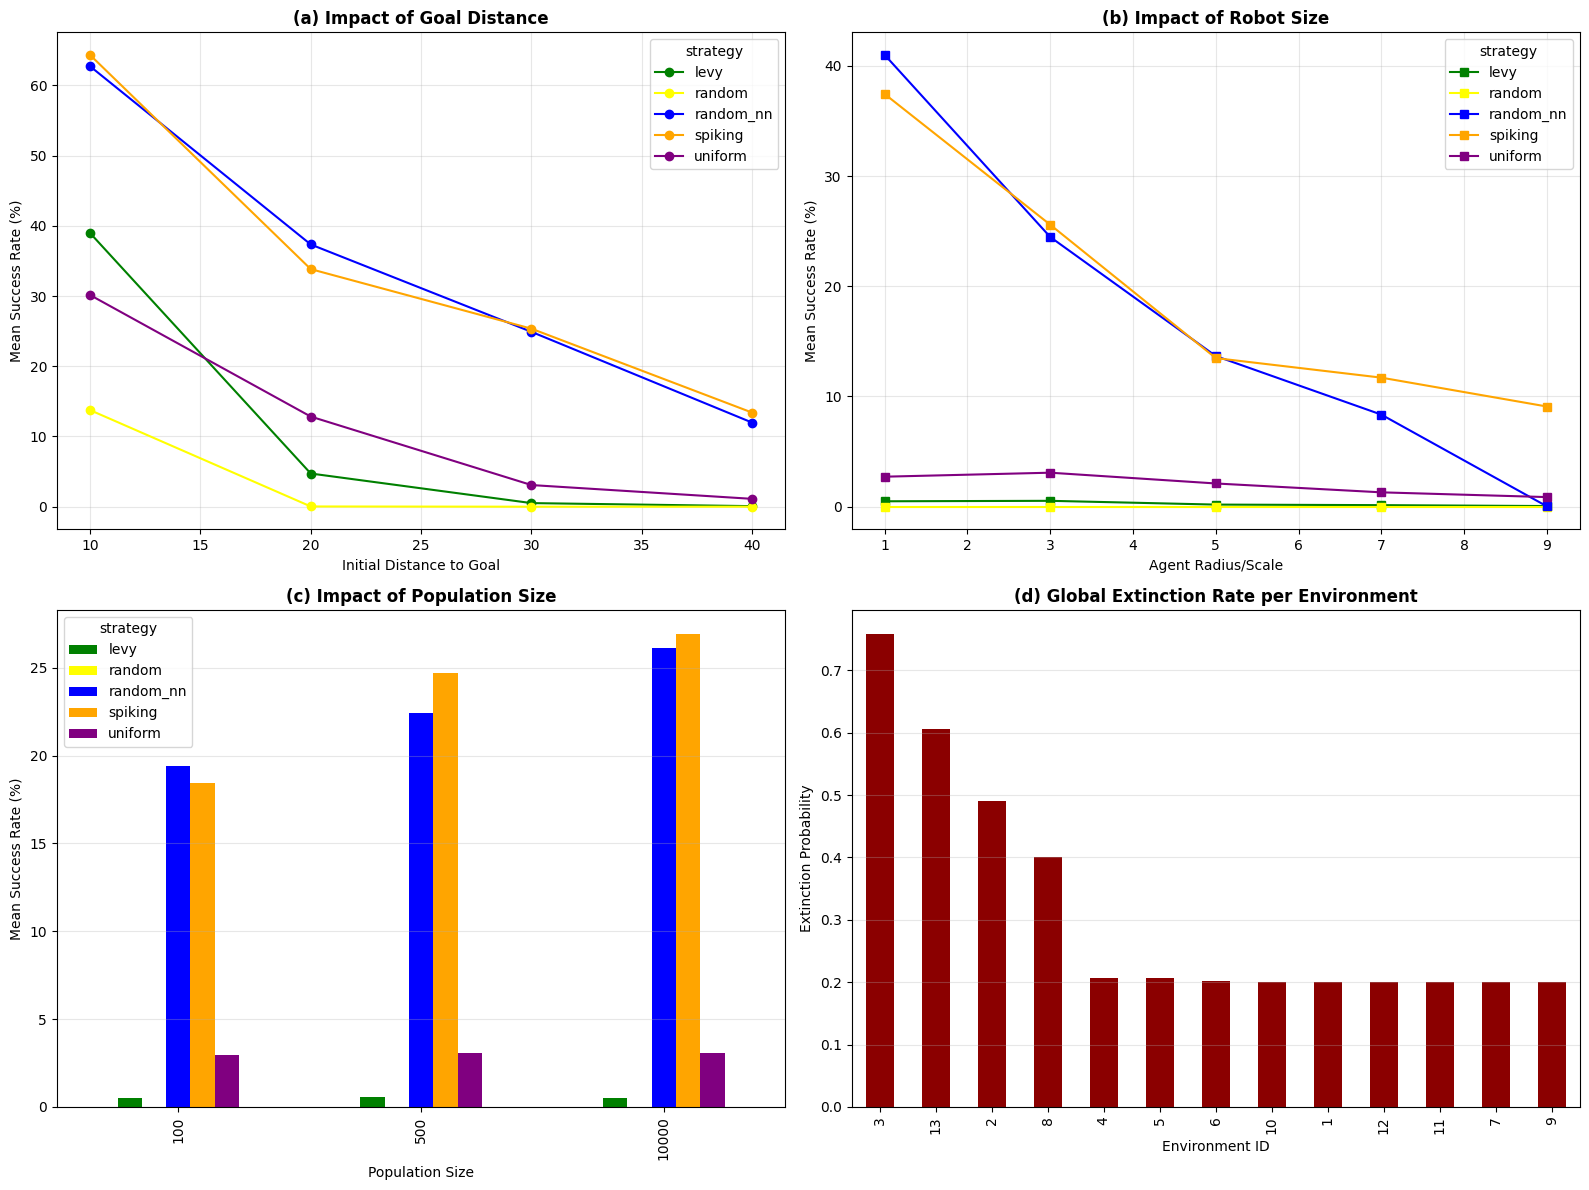

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

colors = {'spiking': 'orange', 'random_nn': 'blue', 'levy': 'green', 'uniform': 'purple', 'random': 'yellow'}

# 1. Goal Distance
dist_df = df[df['parameter'] == 'goal_distance'].copy()
dist_df['val'] = dist_df['parameter_value'].astype(float)
dist_stats = dist_df.groupby(['strategy', 'val'])['success_rate_numeric'].mean().unstack(level=0)

# 2. Robot Size
size_df = df[df['parameter'] == 'robot_size'].copy()
size_df['val'] = size_df['parameter_value'].astype(float)
size_stats = size_df.groupby(['strategy', 'val'])['success_rate_numeric'].mean().unstack(level=0)

# 3. Population Size
pop_df = df[df['parameter'] == 'population'].copy()
pop_df['val'] = pop_df['parameter_value'].astype(int)
pop_stats = pop_df.groupby(['strategy', 'val'])['success_rate_numeric'].mean().unstack(level=0)

# 4. Environment Difficulty (Extinction)
env_df = df[df['parameter'] == 'environment'].copy()
env_df['extinct_bin'] = (env_df['extinct'] == True).astype(int)
env_extinct = env_df.groupby(['parameter_value', 'strategy'])['extinct_bin'].mean().unstack(level=1)
# Average extinction per environment across all strategies
env_avg_extinct = env_extinct.mean(axis=1).sort_values(ascending=False)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Goal Distance
dist_stats.plot(kind='line', marker='o', ax=axes[0, 0], color=[colors.get(c) for c in dist_stats.columns])
axes[0, 0].set_title('(a) Impact of Goal Distance', fontweight='bold')
axes[0, 0].set_xlabel('Initial Distance to Goal')
axes[0, 0].set_ylabel('Mean Success Rate (%)')
axes[0, 0].grid(True, alpha=0.3)

# (b) Robot Size
size_stats.plot(kind='line', marker='s', ax=axes[0, 1], color=[colors.get(c) for c in size_stats.columns])
axes[0, 1].set_title('(b) Impact of Robot Size', fontweight='bold')
axes[0, 1].set_xlabel('Agent Radius/Scale')
axes[0, 1].set_ylabel('Mean Success Rate (%)')
axes[0, 1].grid(True, alpha=0.3)

# (c) Population Size
pop_stats.plot(kind='bar', ax=axes[1, 0], color=[colors.get(c) for c in pop_stats.columns])
axes[1, 0].set_title('(c) Impact of Population Size', fontweight='bold')
axes[1, 0].set_xlabel('Population Size')
axes[1, 0].set_ylabel('Mean Success Rate (%)')
axes[1, 0].grid(True, axis='y', alpha=0.3)

# (d) Environment Extinction
env_avg_extinct.plot(kind='bar', ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('(d) Global Extinction Rate per Environment', fontweight='bold')
axes[1, 1].set_xlabel('Environment ID')
axes[1, 1].set_ylabel('Extinction Probability')
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../output/experiments/figures/environmental_embodiment_analysis.png', dpi=150)

# Final report data
print("Extinction by Env (Selected):")
print(env_extinct.loc[['3', '8', '13']])
print("\nSuccess by Env (Selected):")
env_success = env_df.groupby(['parameter_value', 'strategy'])['success_rate_numeric'].mean().unstack(level=1)
print(env_success.loc[['3', '8', '13']])

### Population Effect 

In [54]:
import pandas as pd

df = pd.read_csv('../output/combined_results.csv', low_memory=False)

# Filter for population parameter
pop_df = df[df['parameter'] == 'population'].copy()

# Look at unique population sizes
print("Unique population values:", pop_df['parameter_value'].unique())

# Group by population size and strategy to see max generations reached per trial
trial_summary = pop_df.groupby(['parameter_value', 'strategy', 'trial'])['generation'].max().reset_index()

# Check for population = 100 specifically
pop_100 = trial_summary[trial_summary['parameter_value'] == '100']
print("\nTrial max generations for population = 100:")
print(pop_100.to_string(index=False))

# Let's count how many trials hit 200 generations per strategy at pop=100
print("\nNumber of trials reaching 200 generations at pop=100:")
print(pop_100[pop_100['generation'] == 200].groupby('strategy').size())

# Let's also check if any trials went extinct early
pop_100_extinct = pop_df[pop_df['parameter_value'] == '100'].groupby(['strategy', 'trial'])['extinct'].last().reset_index()
print("\nExtinction status at the end of trials for pop=100:")
print(pop_100_extinct.to_string(index=False))

Unique population values: ['100' '10000' '500']

Trial max generations for population = 100:
parameter_value  strategy  trial  generation
            100      levy      1           3
            100      levy      2           1
            100      levy      3           1
            100      levy      4           2
            100      levy      5           3
            100      levy      6           1
            100      levy      7           1
            100    random      1           1
            100    random      2           1
            100    random      3           1
            100    random      4           1
            100    random      5           1
            100    random      6           1
            100    random      7           1
            100 random_nn      1           1
            100 random_nn      2           3
            100 random_nn      3         200
            100 random_nn      4         200
            100 random_nn      5           1
       

### Draw Envs 

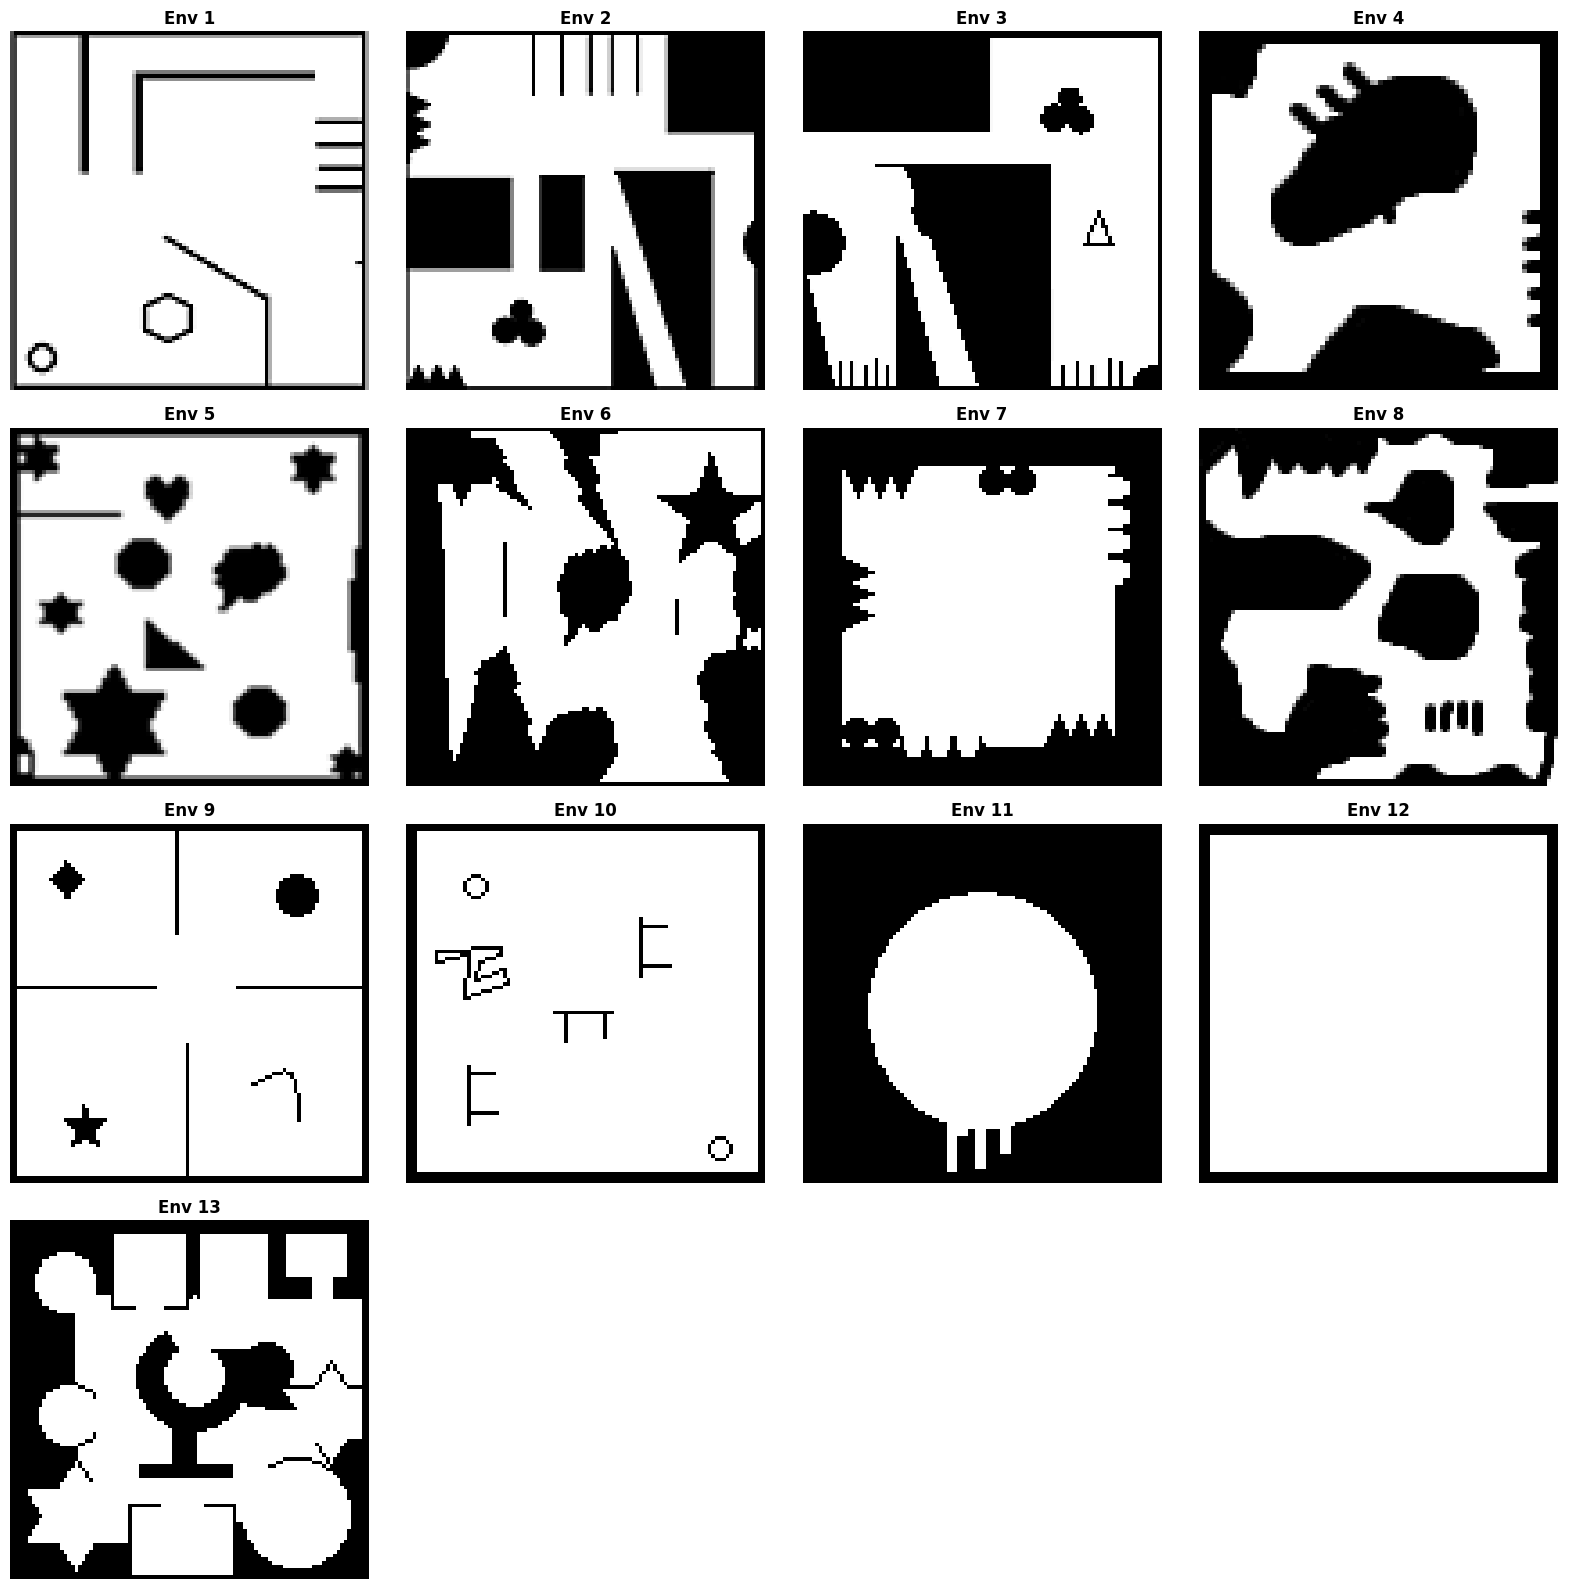

In [48]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import math

def draw_environment_grid(image_dir, grid_size=(4, 4)):
    # Get all .png files in the directory
    valid_extensions = ('.png')
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_extensions)]
    
    # Sort files numerically or alphabetically
    # If files are numbers like '1.png', '10.png', etc., we sort them numerically
    try:
        image_files.sort(key=lambda x: int(os.path.splitext(x)[0]))
    except ValueError:
        image_files.sort()

    rows, cols = grid_size
    fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
    fig.patch.set_facecolor('white')

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        
        if i < len(image_files):
            img_path = os.path.join(image_dir, image_files[i])
            img_name = os.path.splitext(image_files[i])[0] # Name before .png
            
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(f"Env {img_name}", fontsize=12, fontweight='bold')
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\n{img_name}", ha='center', va='center')
        
        # Clean up the axes
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('../output/experiments/figures/environment_grid.png', dpi=300, bbox_inches='tight')
    plt.show()

# Change 'maps' to the actual path where your .png files are stored
# For example: image_folder = './environments'
image_folder = '../environments/images' 

if os.path.exists(image_folder):
    draw_environment_grid(image_folder)
else:
    print(f"Directory '{image_folder}' not found. Please update the path in the script.")

### Environment Performance

In [56]:
import pandas as pd
import numpy as np

df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

env_df = df[df['parameter'] == 'environment'].copy()

# 1. Total number of trials
print("Total trials in environment parameter:", env_df.groupby(['parameter_value', 'strategy', 'trial']).size().shape[0])

# Get max generation for each trial
trial_max = env_df.groupby(['parameter_value', 'strategy', 'trial'])['generation'].max().reset_index()

# Short trials are trials where max generation < 200
short_trials = trial_max[trial_max['generation'] < 200]
print(f"Total short trials (<200 generations): {len(short_trials)} out of {len(trial_max)}")

# Break down short trials by strategy
print("\nShort trials by strategy:")
print(short_trials['strategy'].value_counts())

# Check random strategy max generations
random_max_gens = trial_max[trial_max['strategy'] == 'random']['generation']
print("\nRandom strategy max generations value counts:")
print(random_max_gens.value_counts())

# 2. Environment 3 check
print("\nEnvironment 3 max generations per strategy:")
env3_trials = trial_max[trial_max['parameter_value'] == '3']
print(env3_trials.groupby('strategy')['generation'].value_counts())

# 3. Environment 13, 2, 8 checks
for env_id in ['2', '8', '13']:
    print(f"\nEnvironment {env_id} max generations per strategy:")
    env_sub = trial_max[trial_max['parameter_value'] == env_id]
    print(env_sub.groupby('strategy')['generation'].value_counts())

# 4. Success rate across strategies to see if random_nn or random is the one with zero progress
print("\nMean success rate per strategy in environment experiments:")
print(env_df.groupby('strategy')['success_rate_numeric'].mean())

Total trials in environment parameter: 455
Total short trials (<200 generations): 198 out of 455

Short trials by strategy:
strategy
random       91
levy         48
spiking      28
random_nn    17
uniform      14
Name: count, dtype: int64

Random strategy max generations value counts:
generation
1    91
Name: count, dtype: int64

Environment 3 max generations per strategy:
strategy   generation
levy       1             5
           2             1
           3             1
random     1             7
random_nn  1             7
spiking    1             7
uniform    2             1
           3             1
           4             1
           13            1
           15            1
           16            1
           20            1
Name: count, dtype: int64

Environment 2 max generations per strategy:
strategy   generation
levy       2             3
           1             2
           4             2
random     1             7
random_nn  1             5
           200         

In [57]:
# Check exactly which environments Uniform failed to reach 200 generations
uniform_by_env = trial_max[trial_max['strategy'] == 'uniform']
print(uniform_by_env[uniform_by_env['generation'] < 200])

    parameter_value strategy  trial  generation
168              13  uniform      1          64
169              13  uniform      2          75
170              13  uniform      3          81
171              13  uniform      4          54
172              13  uniform      5          41
173              13  uniform      6          30
174              13  uniform      7          50
238               3  uniform      1          13
239               3  uniform      2          16
240               3  uniform      3           2
241               3  uniform      4          15
242               3  uniform      5           3
243               3  uniform      6           4
244               3  uniform      7          20


In [60]:
# Create a pivot table of survival counts (trials reaching Gen 200) per environment and strategy
trial_max['survived'] = (trial_max['generation'] == 200).astype(int)
survival_pivot = trial_max.pivot_table(index='parameter_value', columns='strategy', values='survived', aggfunc='sum')

# Ensure index is sorted numerically for clean viewing
survival_pivot.index = survival_pivot.index.astype(int)
survival_pivot = survival_pivot.sort_index()

print("Survival Counts (out of 7 trials) per Environment and Strategy:")
print(survival_pivot)

# Plotting a clear heatmap of survival counts for the paper/validation
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(survival_pivot, annot=True, cmap='YlGnBu', fmt='d', cbar_kws={'label': 'Surviving Trials (out of 7)'})
plt.title('Trial Survival Count per Environment and Strategy (Target: 200 Gens)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Strategy', fontsize=12)
plt.ylabel('Environment ID', fontsize=12)
plt.tight_layout()
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'environment_survival_heatmap.png'), dpi=300)
plt.close()

Survival Counts (out of 7 trials) per Environment and Strategy:
strategy         levy  random  random_nn  spiking  uniform
parameter_value                                           
1                   7       0          7        7        7
2                   0       0          2        0        7
3                   0       0          0        0        0
4                   0       0          7        7        7
5                   0       0          7        7        7
6                   2       0          7        7        7
7                   7       0          7        7        7
8                   3       0          7        0        7
9                   7       0          7        7        7
10                  3       0          7        7        7
11                  7       0          7        7        7
12                  7       0          7        7        7
13                  0       0          2        0        0


## Robustness to Noise and Delay

Noise stats generated.

Sensor Noise Summary:
strategy        random_nn    spiking
Type     Level                      
Baseline 0.00   24.161032  26.252643
Dropout  0.05   23.020857  18.736643
         0.10   18.350500  16.714214
         0.20   17.292357  15.518857
Gaussian 2.00   24.627214  25.910643
         5.00   25.065857  25.448643
         10.00  23.642500  24.077357
Uniform  5.00   23.871071  25.459929
         10.00  24.428571  25.798286
         20.00  22.788786  24.134214

Actuator Noise Summary:
strategy        random_nn    spiking
Type     Level                      
Baseline 0.00   24.470608  25.575643
Deadzone 0.05   24.057857  25.672214
         0.10   24.511714  25.808000
         0.20   24.717786  25.952286
         0.50   23.860786  25.504357
Slip     0.05   24.017319  25.268071
         0.10   24.175021  26.082643
         0.20   24.590071  25.305286
         0.30   22.336491  22.992000

Latency Summary:
strategy  random_nn    spiking
Steps                        

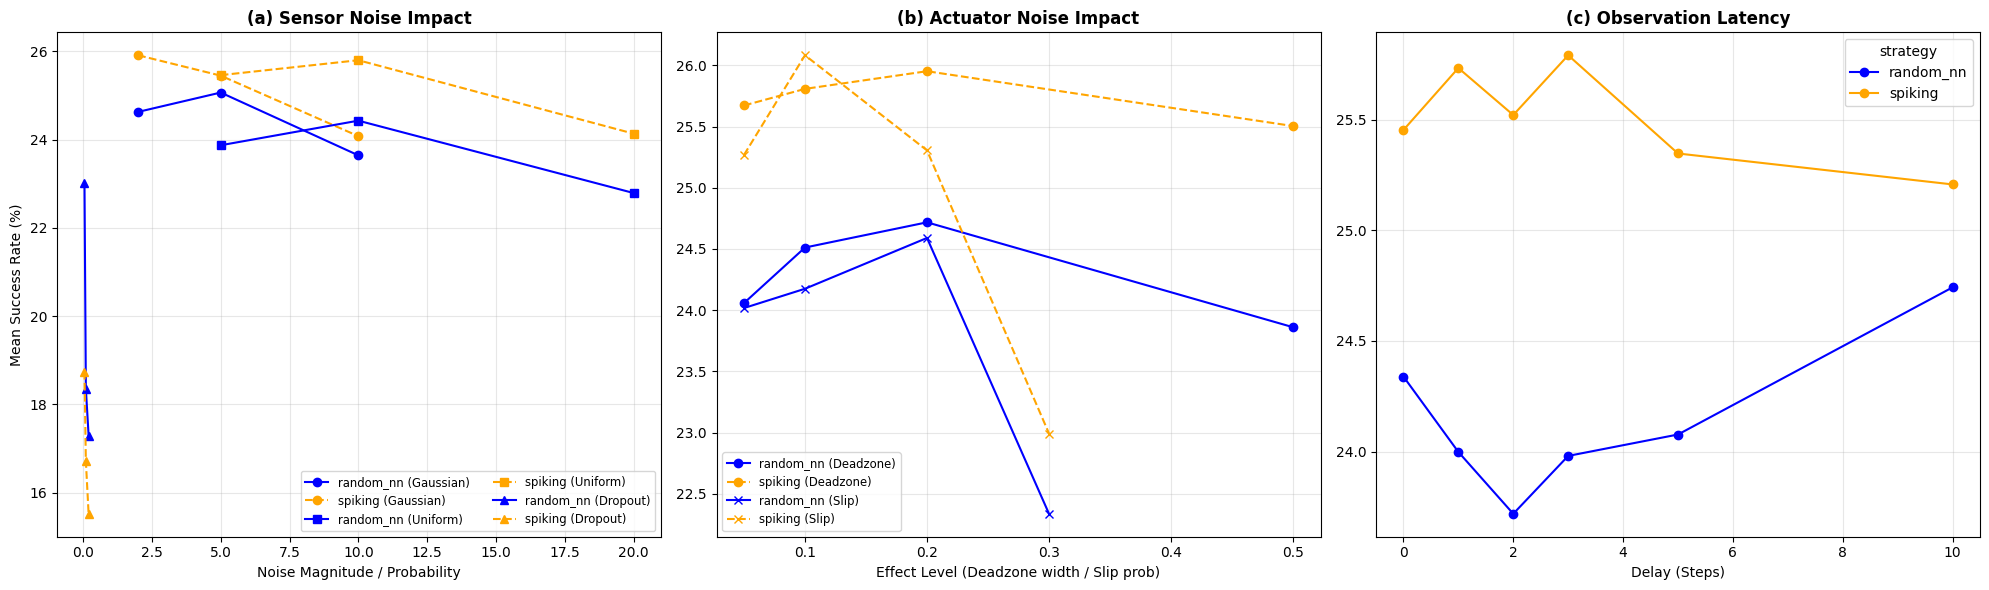

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

colors = {'spiking': 'orange', 'random_nn': 'blue'}

# --- 4.7.1 Sensor Noise ---
sensor_df = df[df['parameter'] == 'noise_sensor'].copy()
# Categorize sensor noise
def categorize_sensor(val):
    if 'baseline' in val: return 'Baseline', 0
    type_name = val.split('_')[0]
    amount = float(''.join(c for c in val.split('_')[1] if c.isdigit() or c == '.'))
    return type_name.capitalize(), amount

sensor_df[['Type', 'Level']] = sensor_df['parameter_value'].apply(lambda x: pd.Series(categorize_sensor(x)))
sensor_stats = sensor_df.groupby(['strategy', 'Type', 'Level'])['success_rate_numeric'].mean().unstack(level=0)

# --- 4.7.2 Actuator Noise ---
act_df = df[df['parameter'] == 'noise_actuator'].copy()
def categorize_act(val):
    if 'baseline' in val: return 'Baseline', 0
    parts = val.split('_')
    type_name = parts[2] # deadzone or slip
    if type_name == 'deadzone':
        return 'Deadzone', float(parts[3])
    else:
        # For slip, use prob as level
        return 'Slip', float(parts[3].replace('prob', ''))

act_df[['Type', 'Level']] = act_df['parameter_value'].apply(lambda x: pd.Series(categorize_act(x)))
act_stats = act_df.groupby(['strategy', 'Type', 'Level'])['success_rate_numeric'].mean().unstack(level=0)

# --- 4.7.3 Latency ---
lat_df = df[df['parameter'] == 'noise_latency'].copy()
def categorize_lat(val):
    if 'baseline' in val: return 0
    return int(''.join(c for c in val if c.isdigit()))

lat_df['Steps'] = lat_df['parameter_value'].apply(categorize_lat)
lat_stats = lat_df.groupby(['strategy', 'Steps'])['success_rate_numeric'].mean().unstack(level=0)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Sensor Noise (Using Gaussian as representative for line plot, or separate lines)
for t in ['Gaussian', 'Uniform', 'Dropout']:
    sub = sensor_stats.xs(t, level='Type')
    for strat in sub.columns:
        marker = 'o' if t == 'Gaussian' else ('s' if t == 'Uniform' else '^')
        ls = '-' if strat == 'random_nn' else '--'
        axes[0].plot(sub.index, sub[strat], label=f"{strat} ({t})", color=colors[strat], marker=marker, linestyle=ls)
axes[0].set_title('(a) Sensor Noise Impact', fontweight='bold')
axes[0].set_xlabel('Noise Magnitude / Probability')
axes[0].set_ylabel('Mean Success Rate (%)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize='small', ncol=2)

# (b) Actuator Noise
for t in ['Deadzone', 'Slip']:
    sub = act_stats.xs(t, level='Type')
    for strat in sub.columns:
        marker = 'o' if t == 'Deadzone' else 'x'
        ls = '-' if strat == 'random_nn' else '--'
        axes[1].plot(sub.index, sub[strat], label=f"{strat} ({t})", color=colors[strat], marker=marker, linestyle=ls)
axes[1].set_title('(b) Actuator Noise Impact', fontweight='bold')
axes[1].set_xlabel('Effect Level (Deadzone width / Slip prob)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize='small')

# (c) Latency
lat_stats.plot(kind='line', marker='o', ax=axes[2], color=[colors.get(c) for c in lat_stats.columns])
axes[2].set_title('(c) Observation Latency', fontweight='bold')
axes[2].set_xlabel('Delay (Steps)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/experiments/figures/noise_robustness_analysis.png', dpi=150)

print("Noise stats generated.")
print("\nSensor Noise Summary:")
print(sensor_stats)
print("\nActuator Noise Summary:")
print(act_stats)
print("\nLatency Summary:")
print(lat_stats)

## Action 

In [51]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

# Filter for action representation experiments
action_df = df[df['parameter'] == 'action'].copy()

# Categorize
action_df['Type'] = action_df['parameter_value'].apply(lambda x: 'Continuous' if 'continuous' in x else 'Discrete')

# Aggregate by Type and Trial to get per-trial max generation
trial_survival = action_df.groupby(['Type', 'strategy', 'trial'])['generation'].max().reset_index()

# Final performance stats (take the last generation per trial)
last_gens = action_df.groupby(['Type', 'strategy', 'trial'])['generation'].idxmax()
final_action_stats = action_df.loc[last_gens].copy()

# Summary Table
summary = final_action_stats.groupby('Type').agg({
    'generation': 'mean', # Average survival length
    'success_rate_numeric': 'mean',
    'avg_path_length': 'mean',
    'avg_energy_remaining': 'mean',
    'avg_health_remaining': 'mean'
})

# Calculate extinction rate: trials that ended before gen 200
# (Assuming the experiment was meant to go to 200)
def calc_extinction(group):
    return (group < 200).sum() / len(group)

extinction = trial_survival.groupby('Type')['generation'].apply(calc_extinction)
summary['extinction_rate'] = extinction

print("Continuous vs Discrete Comparison Table:")
print(summary.round(2))

# Let's break it down by strategy as well for more detail
strategy_summary = final_action_stats.groupby(['strategy', 'Type']).agg({
    'generation': 'mean',
    'success_rate_numeric': 'mean',
    'avg_path_length': 'mean',
    'avg_energy_remaining': 'mean',
    'avg_health_remaining': 'mean'
})
print("\nBreakdown by Strategy:")
print(strategy_summary.round(2))

Continuous vs Discrete Comparison Table:
            generation  success_rate_numeric  avg_path_length  \
Type                                                            
Continuous      185.79                 19.54           443.42   
Discrete        185.79                 30.99           422.90   

            avg_energy_remaining  avg_health_remaining  extinction_rate  
Type                                                                     
Continuous                485.16                446.01             0.07  
Discrete                  505.67                458.52             0.07  

Breakdown by Strategy:
                      generation  success_rate_numeric  avg_path_length  \
strategy  Type                                                            
random_nn Continuous      171.57                 20.96           475.06   
          Discrete        171.57                 28.51           352.96   
spiking   Continuous      200.00                 18.13           411.78   
   

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('../output/combined_results.csv', low_memory=False)
df['success_rate_numeric'] = df['success_rate_percent'].str.rstrip('%').astype(float)

# Filter for action parameter
action_df = df[df['parameter'] == 'action'].copy()

# Map parameter values to cleaner names
action_map = {
    'continuous_deterministic': 'Continuous Det',
    'continuous_stochastic': 'Continuous Stoch',
    'discrete_deterministic': 'Discrete Det',
    'discrete_stochastic': 'Discrete Stoch'
}
action_df['action_type'] = action_df['parameter_value'].map(action_map)

# Styles for action types
styles = {
    'Discrete Det': '-',
    'Discrete Stoch': '--',
    'Continuous Det': ':',
    'Continuous Stoch': '-.'
}

strategies = ['random_nn', 'spiking']
colors = {'random_nn': 'blue', 'spiking': 'orange'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, strategy in enumerate(strategies):
    ax = axes[i]
    strat_df = action_df[action_df['strategy'] == strategy]
    
    # Check max generations
    max_gen = 200
    
    for action_type, style in styles.items():
        subset = strat_df[strat_df['action_type'] == action_type]
        if subset.empty: continue
        
        # Group by generation and average success rate
        # Using first 7 trials
        trials = subset['trial'].unique()[:7]
        subset = subset[subset['trial'].isin(trials)]
        
        curves = subset.groupby('generation')['success_rate_numeric'].mean().sort_index()
        curves = curves[curves.index <= max_gen]
        
        ax.plot(curves.index, curves.values, label=action_type, 
                color=colors[strategy], linestyle=style, linewidth=2)
        
        # Print final mean to verify table
        final_val = curves.iloc[-1] if not curves.empty else 0
        print(f"{strategy} | {action_type} | Final Gen Mean: {final_val:.2f}%")

    ax.set_title(f'Learning Curves: {strategy.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Generation', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

axes[0].set_ylabel('Mean Success Rate (%)', fontsize=12)
plt.suptitle('Effect of Action Representation on Learning Success', fontsize=16, y=1.02)
plt.tight_layout()
dir = '../output/experiments/figures'
os.makedirs(dir, exist_ok=True)
plt.savefig(os.path.join(dir, 'action_representation_curves.png'), dpi=300, bbox_inches='tight')
plt.close()

random_nn | Discrete Det | Final Gen Mean: 33.27%
random_nn | Discrete Stoch | Final Gen Mean: 34.00%
random_nn | Continuous Det | Final Gen Mean: 23.96%
random_nn | Continuous Stoch | Final Gen Mean: 27.84%
spiking | Discrete Det | Final Gen Mean: 33.46%
spiking | Discrete Stoch | Final Gen Mean: 31.24%
spiking | Continuous Det | Final Gen Mean: 19.42%
spiking | Continuous Stoch | Final Gen Mean: 10.91%
